In [ ]:
RANDOM_STATE = 42

def set_seeds(seed: int = 42):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

set_seeds(RANDOM_STATE)

In [ ]:
# Load Dataset

import pandas as pd

DATA_PATH = "/content/Structural_&_Wall_Dataset.csv"
df = pd.read_csv(DATA_PATH)

print(" Shape:", df.shape)
display(df.head())

 Shape: (2400, 5)


,wall_type,floor_area_m2,total_wall_area_m2,labor_count,duration_days
0,Brick,270.8,500.0,18,11
1,Concrete Block,207.1,332.8,19,7
2,Brick,160.2,328.4,16,9
3,Concrete Block,156.4,274.2,20,6
4,Concrete Block,145.7,215.3,20,6


In [ ]:
print(df.dtypes)

wall_type              object
floor_area_m2         float64
total_wall_area_m2    float64
labor_count             int64
duration_days           int64
dtype: object


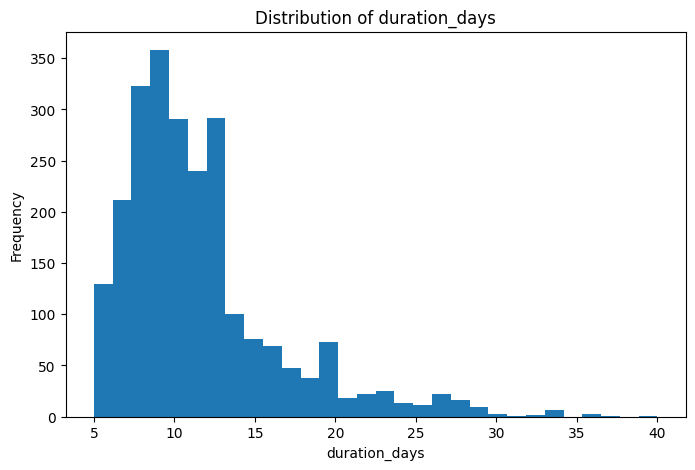

In [ ]:
#  Target Distribution

import matplotlib.pyplot as plt

possible_targets = ["Duration_Days", "Duration_days", "duration_days", "duration"]
TARGET_COL = next((c for c in possible_targets if c in df.columns), None)

if TARGET_COL is None:
    raise ValueError(f"Target column not found. Checked: {possible_targets}. Found columns: {df.columns.tolist()}")

plt.figure(figsize=(8, 5))
plt.hist(df[TARGET_COL], bins=30)
plt.title(f"Distribution of {TARGET_COL}")
plt.xlabel(TARGET_COL)
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Preprocessing Functions

def split_features_target(df, target_col: str):
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].copy()
    return X, y

def build_preprocessor(X, scale_numeric: bool):
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))
    num_pipe = Pipeline(steps=num_steps)

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols)
        ],
        remainder="drop"
    )
    return preprocessor

In [ ]:
#  Train/Test Split

from sklearn.model_selection import train_test_split

X, y = split_features_target(df, TARGET_COL)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

Train = (len(X_train) / len(X)) * 100
Test = (len(X_test) / len(X)) * 100

print(f" Train Percentage: {Train:.0f}%")
print(f"Test Percentage: {Test:.0f}%")

 Train Percentage: 80%
Test Percentage: 20%


In [ ]:
# Model Training Functions

# Linear Regression

def train_linear_regression(X_train, y_train):
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LinearRegression

    preprocessor = build_preprocessor(X_train, scale_numeric=True)
    model = LinearRegression()

    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    return pipe


In [ ]:
# Random Forest Regressor

def train_random_forest(X_train, y_train, random_state=42):
    from sklearn.pipeline import Pipeline
    from sklearn.ensemble import RandomForestRegressor

    preprocessor = build_preprocessor(X_train, scale_numeric=False)
    model = RandomForestRegressor(
        n_estimators=300,
        random_state=random_state,
        n_jobs=-1
    )

    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    return pipe

In [ ]:
lr_model = train_linear_regression(X_train, y_train)
rf_model = train_random_forest(X_train, y_train, random_state=RANDOM_STATE)


print(" All models trained.")

 All models trained.


In [ ]:
#  Evaluation Functions


import numpy as np

def regression_accuracy_within_tolerance(y_true, y_pred, tolerance=0.10):
    """
    Accuracy = % predictions within ±tolerance of true value
    tolerance=0.10 means ±10%
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denom = np.where(y_true == 0, 1.0, y_true)  # safe divide
    rel_err = np.abs(y_pred - y_true) / np.abs(denom)

    return float(np.mean(rel_err <= tolerance))

def evaluate_model(name, model, X_test, y_test):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    acc10 = regression_accuracy_within_tolerance(y_test, pred, tolerance=0.10)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Accuracy_±10%": acc10
    }

In [ ]:
#  Evaluate All Models + Comparison Table

import pandas as pd

results = []
results.append(evaluate_model("Linear Regression", lr_model, X_test, y_test))
results.append(evaluate_model("Random Forest", rf_model, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("MAE", ascending=True)
display(results_df)

,Model,MAE,RMSE,R2,Accuracy_±10%
1,Random Forest,0.590486,0.920856,0.968651,0.885417
0,Linear Regression,1.976996,2.798493,0.710478,0.322917


In [ ]:

#  Select Best Model (Lowest MAE)

best_row = results_df.iloc[0]
best_name = best_row["Model"]

best_model = {
    "Linear Regression": lr_model,
    "Random Forest": rf_model
}[best_name]

print(" Best Model:", best_name)
print("MAE:", best_row["MAE"])
print("RMSE:", best_row["RMSE"])
print("R²:", best_row["R2"])
print("Accuracy :", best_row["Accuracy_±10%"])

 Best Model: Random Forest
MAE: 0.590486111111111
RMSE: 0.9208564602425128
R²: 0.9686514911417629
Accuracy : 0.8854166666666666


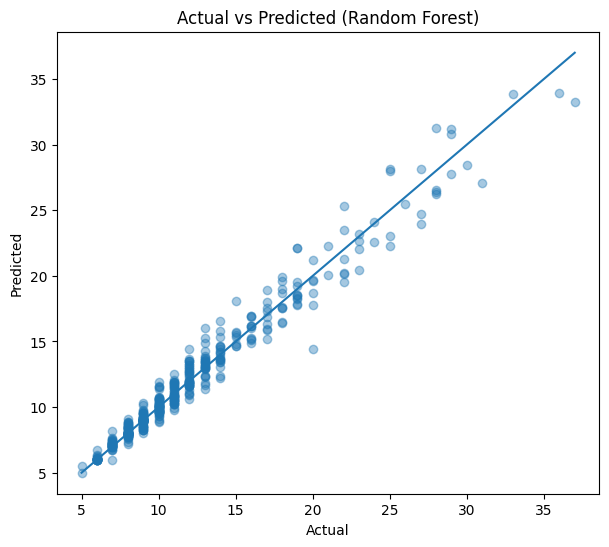

In [ ]:
#  Actual vs Predicted (Best Model)

import matplotlib.pyplot as plt

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4)
plt.title(f"Actual vs Predicted ({best_name})")
plt.xlabel("Actual")
plt.ylabel("Predicted")

# 45-degree line
min_v = min(y_test.min(), y_pred_best.min())
max_v = max(y_test.max(), y_pred_best.max())
plt.plot([min_v, max_v], [min_v, max_v])

plt.show()

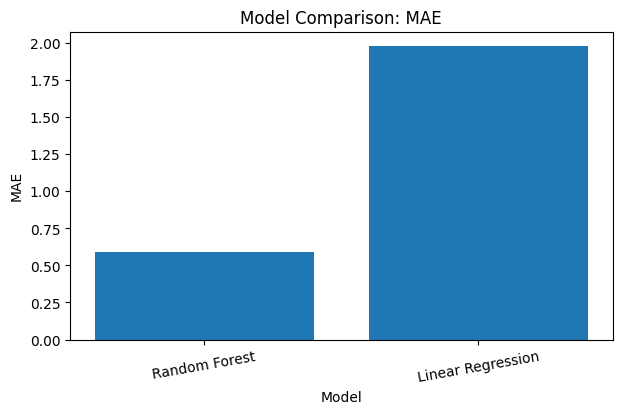

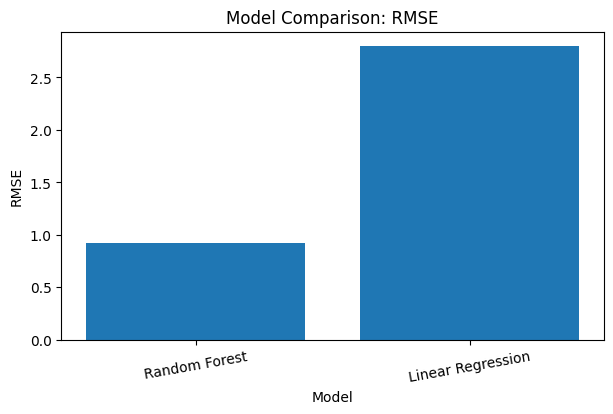

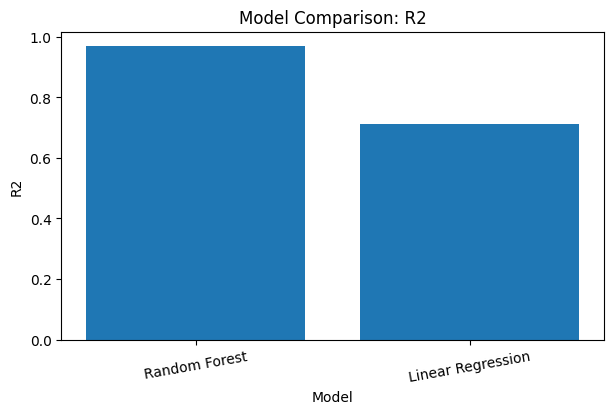

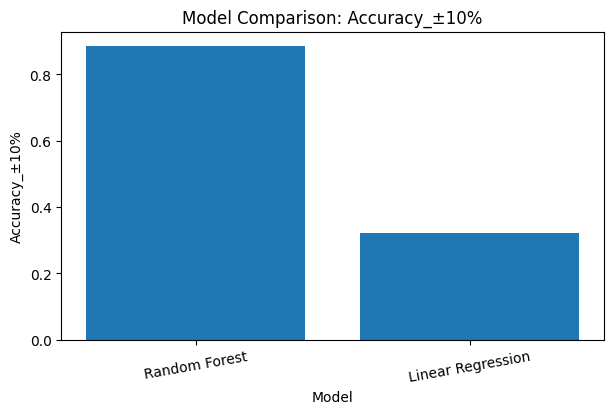

In [ ]:
#  Model Comparison Bar Charts

metrics = ["MAE", "RMSE", "R2", "Accuracy_±10%"]

for metric in metrics:
    plt.figure(figsize=(7, 4))
    plt.bar(results_df["Model"], results_df[metric])
    plt.title(f"Model Comparison: {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=10)
    plt.show()

In [ ]:
#  Save Best Pipeline

import joblib

SAVE_PATH = "wall_pipeline.pkl"
joblib.dump(best_model, SAVE_PATH)

print(f" Saved best model pipeline to: {SAVE_PATH}")

 Saved best model pipeline to: wall_pipeline.pkl


In [ ]:

#  Load Saved Model

import joblib
import pandas as pd

loaded_model = joblib.load("wall_pipeline.pkl")

new_input = pd.DataFrame([{

    "wall_type": "Concrete Block",
    "floor_area_m2":120 ,
    "total_wall_area_m2": 345,
    "working_hours_per_day": 8,
    "labor_count": 8
}])

pred = loaded_model.predict(new_input)[0]

print(" New Input:")
display(new_input)

print(f" Predicted Duration_Days: {pred:.0f} days")

 New Input:


,wall_type,floor_area_m2,total_wall_area_m2,working_hours_per_day,labor_count
0,Concrete Block,120,345,8,8


 Predicted Duration_Days: 10 days


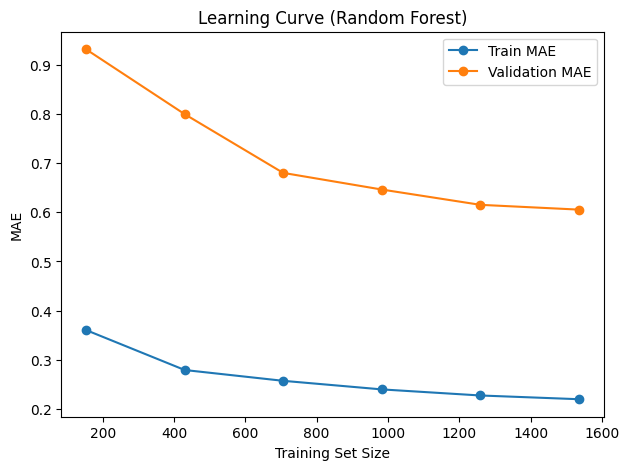

In [ ]:

# Learning Curve

def plot_learning_curve(model, X, y, title="Learning Curve"):
    from sklearn.model_selection import learning_curve
    import numpy as np
    import matplotlib.pyplot as plt

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X, y,
        cv=5,
        scoring="neg_mean_absolute_error",
        train_sizes=np.linspace(0.1, 1.0, 6),
        n_jobs=-1,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    train_mae = -train_scores.mean(axis=1)
    val_mae = -val_scores.mean(axis=1)

    plt.figure(figsize=(7, 5))
    plt.plot(train_sizes, train_mae, marker="o", label="Train MAE")
    plt.plot(train_sizes, val_mae, marker="o", label="Validation MAE")
    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel("MAE")
    plt.legend()
    plt.show()

plot_learning_curve(best_model, X_train, y_train, title=f"Learning Curve ({best_name})")